# import necessary libraries

In [158]:
#import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# load datasets

In [159]:
df1=pd.read_csv("historical_data (1).csv")
df2=pd.read_csv("fear_greed_index (1).csv")
df1.head()
df2.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# number of row and columns

In [160]:
print("number of row and columns in the historical_data(df1)is:",df1.shape)
print("number of row and columns in the fear_greed_index(df2)is:",df2.shape)

number of row and columns in the historical_data(df1)is: (211224, 16)
number of row and columns in the fear_greed_index(df2)is: (2644, 4)


# missing values / duplicates

In [161]:
#missing values 
print("number of missing values in the historical_data(df1)is:",df1.isna().sum())
print("number of missing values in the fear_greed_index(df2)is:",df2.isna().sum())
#duplicate values
print("number of duplicate values in the historical_data(df1)is:",df1.duplicated().sum())
print("number of duplicate values in the fear_greed_index(df2)is:",df2.duplicated().sum())

number of missing values in the historical_data(df1)is: Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
number of missing values in the fear_greed_index(df2)is: timestamp         0
value             0
classification    0
date              0
dtype: int64
number of duplicate values in the historical_data(df1)is: 0
number of duplicate values in the fear_greed_index(df2)is: 0



# timestamps and align the datasets by date

In [162]:
#coverting time stamp to date time
df1["time_stamp"]=pd.to_datetime(df1["Timestamp"], unit="ms")
#extracting the date from the date_time
df1["date"]=df1["time_stamp"].dt.date
#covert int to date
df2["date"]=pd.to_datetime(df2["date"]).dt.date
#merging the df1 and df2 on date
df3=pd.merge(df1,df2,on="date",how="left")
df3 = df3.dropna(subset=["classification"])

In [163]:
df3.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,time_stamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed


In [164]:
#daily PnL per trader
df3.groupby(["Account","date"])["Closed PnL"].sum()
#average PnL per day
df3.groupby("date")["Closed PnL"].mean()


date
2023-03-28     0.000000
2023-11-14     0.148807
2024-03-09    25.418772
2024-07-03    22.229713
2024-10-27    90.504272
2025-02-19    50.047622
Name: Closed PnL, dtype: float64

# win rate, average trade size

In [165]:
#winrate print
df3["win_rate"]=df3["Closed PnL"]>0
print("the win rate is ",df3["win_rate"].mean())
#printing the average trade size
df3.groupby("classification")["Size USD"].mean()
#printing the tradesize per trade
df3.groupby("Account")["Size USD"].mean()

the win rate is  0.4203502602258728


Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1759.743439
0x271b280974205ca63b716753467d5a371de622ab    10908.183944
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      509.016502
0x2c229d22b100a7beb69122eed721cee9b24011dd     3142.909573
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     1894.041896
0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
0x430f09841d65beb3f27765503d0f850b8bce7713     2580.497012
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      520.720626
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     8954.378674
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17091.235308
0x513b8629fe877bb581bf244e326a047b249c4ff1    27373.685203
0x6d6a4b953f202f8df5bed40692e7fd865318264a      779.878942
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     9561.075256
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     2

### 

# leverage distribution

In [166]:
#for calculation the leverage we need the position size and capital 
#capital is not give so for calculation the capital need the leverage 
#instead of that we insights this
df3["Size USD"].describe()
df3.groupby("classification")["Size USD"].mean()
median_size = df3["Size USD"].median()
df3["size_segment"] = np.where(df3["Size USD"] > median_size, "High", "Low")
df3["size_segment"].head()

0    High
1     Low
2    High
3    High
4     Low
Name: size_segment, dtype: object

# number of trades per day

In [167]:
df3.groupby("date").size()

date
2023-03-28         3
2023-11-14      1045
2024-03-09      6962
2024-07-03      7141
2024-10-27     35241
2025-02-19    133871
dtype: int64

# long/short ratio

In [168]:
long=(df3["Side"]=="BUY").sum()
short=(df3["Side"]=="SELL").sum()
print("long by short ratio is :",long/short)

long by short ratio is : 0.9217082963967252


# (PnL, win rate, drawdown proxy) Fear vs Greed days

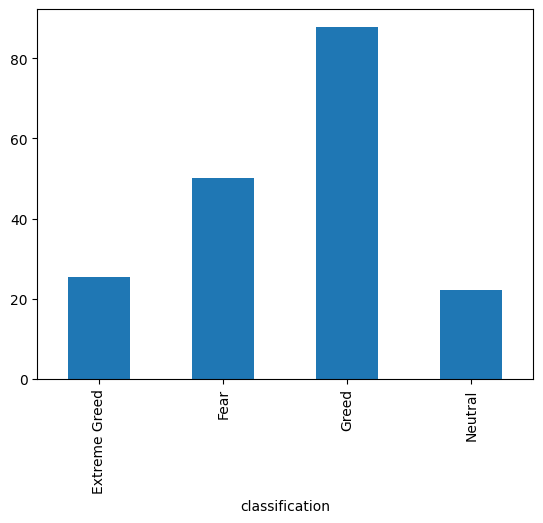

In [169]:
avg_pnl = df3.groupby("classification")["Closed PnL"].mean()
avg_pnl.plot(kind="bar")
plt.show()

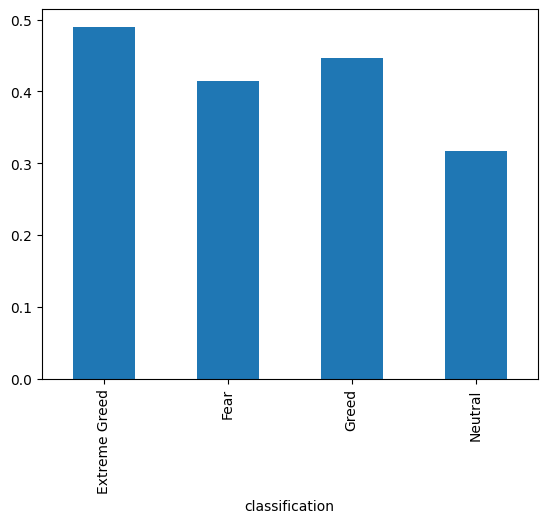

In [170]:
win_rate = df3.groupby("classification")["win_rate"].mean()
win_rate.plot(kind="bar")
plt.show()

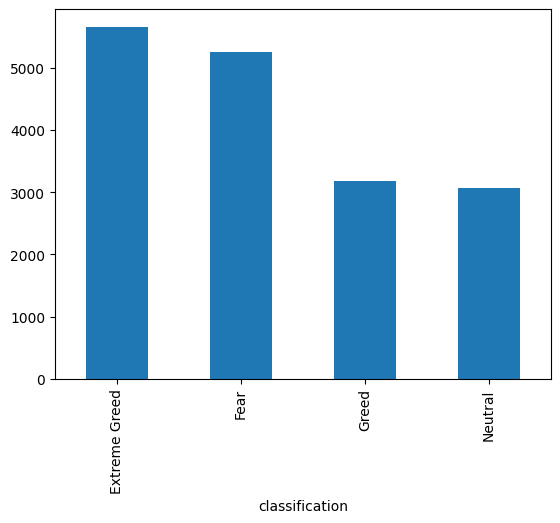

In [171]:
avg_size = df3.groupby("classification")["Size USD"].mean()
avg_size.plot(kind="bar")
plt.show()

In [172]:
trades_per_day = df3.groupby(["Account","date","classification"]).size().reset_index(name="num_trades")
trades_per_day.groupby("classification")["num_trades"].mean()

classification
Extreme Greed    1392.40000
Fear             4183.46875
Greed            1134.03125
Neutral           892.62500
Name: num_trades, dtype: float64

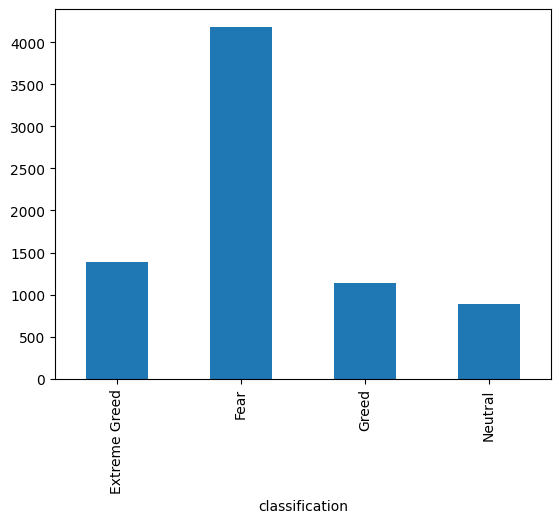

In [173]:
trades_per_day.groupby("classification")["num_trades"].mean().plot(kind="bar")
plt.show()

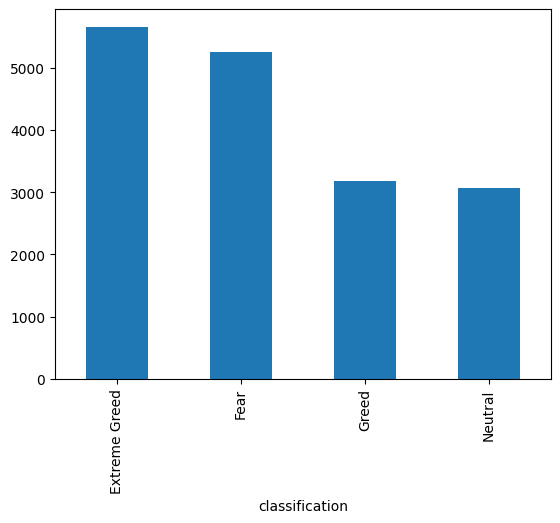

In [174]:
df3.groupby("classification")["Size USD"].mean()
df3.groupby("classification")["Size USD"].mean().plot(kind="bar")
plt.show()

In [175]:
pd.crosstab(df3["classification"],df3["Side"],normalize="index")

Side,BUY,SELL
classification,,
Extreme Greed,0.484200,0.515800
Fear,0.493617,0.506383
Greed,0.424950,0.575050
Neutral,0.490828,0.509172


In [176]:
median_size=df3["Size USD"].median()
df3["size_segment"]=np.where(df3["Size USD"]>median_size,"High","Low")

In [177]:
df3.groupby(["classification","size_segment"])["Closed PnL"].mean()

classification  size_segment
Extreme Greed   High             39.373435
                Low               4.019592
Fear            High             95.337428
                Low               3.187695
Greed           High            175.288360
                Low              12.601238
Neutral         High             49.649426
                Low               1.833999
Name: Closed PnL, dtype: float64

In [179]:
trade_counts=df3.groupby("Account").size()
median_trades=trade_counts.median()
freq_segment=[]
for acc in df3["Account"]:
    if trade_counts[acc]>median_trades:
        freq_segment.append("Frequent")
    else:
        freq_segment.append("Infrequent")

df3["freq_segment"]=freq_segment

# insights-3

In [ ]:
1.traders earn higher average pnl and win rate during greed days compared to fear days.

2.trading activity increases during fear days, showing that traders react more in uncertain markets.

3.traders take larger position sizes during greed periods, indicating higher confidence when sentiment is positive.

# 2 strategy ideas 

In [ ]:
1.during fear days, reduce position size and avoid overtrading to manage risk better.

2.during greed days, slightly increase exposure but maintain disciplined risk control.